<a href="https://colab.research.google.com/github/Riky-18/SVM-Tasks/blob/main/SVM_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 3: SVM – Email Spam Classification

 Features: word_freq_free, word_freq_money, word_freq_offer, email_length<br>
 Target: Spam (1) / Not Spam (0)


 Question:
*   Fit an SVM classifier to detect spam emails.
*   Use 5-fold cross-validation
*   Report accuracy and ROC-AUC
*   Predict if an email with (free=2.1, money=1.3, offer=0.7, length=180) is spam

---






All Imports (Data, Viz & ML)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import SVC

Data Loading & Pandas Inspection



In [ ]:
df = pd.read_csv('email_spam_svm.csv')

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['is_spam'].value_counts())
df.head()

Shape: (150, 5)

Missing Values:
 word_freq_free     0
word_freq_money    0
word_freq_offer    0
email_length       0
is_spam            0
dtype: int64

Class Distribution:
 is_spam
1    146
0      4
Name: count, dtype: int64


,word_freq_free,word_freq_money,word_freq_offer,email_length,is_spam
0,5.88,0.15,6.86,341.2,1
1,0.00,5.76,7.33,474.0,1
2,1.97,5.71,0.69,300.7,1
3,7.80,1.53,3.43,195.2,1
4,3.42,4.20,2.36,68.2,1


Exploratory Data Analysis (EDA with Seaborn & Matplotlib)

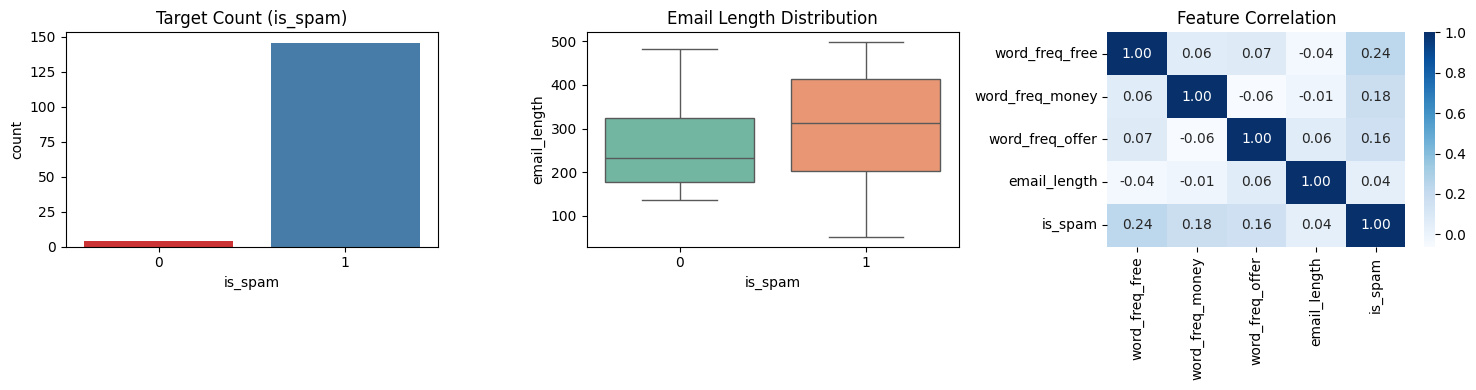

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Target count
sns.countplot(data=df, x='is_spam', hue='is_spam', palette='Set1', legend=False, ax=axes[0])
axes[0].set_title('Target Count (is_spam)')

# 2. Email length vs spam
sns.boxplot(data=df, x='is_spam', y='email_length', hue='is_spam', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Email Length Distribution')

# 3. Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f', ax=axes[2])
axes[2].set_title('Feature Correlation')

plt.tight_layout()
plt.show()

Feature Engineering

In [ ]:
# Engineering a new feature: Total trigger words frequency
df['total_trigger_words'] = (
    df['word_freq_free'] + df['word_freq_money'] + df['word_freq_offer']
)

# Feature matrix (X) and Target vector (y)
feature_cols = [
    'word_freq_free',
    'word_freq_money',
    'word_freq_offer',
    'email_length',
    'total_trigger_words'
]

X = df[feature_cols]
y = df['is_spam']

X.head()

,word_freq_free,word_freq_money,word_freq_offer,email_length,total_trigger_words
0,5.88,0.15,6.86,341.2,12.89
1,0.00,5.76,7.33,474.0,13.09
2,1.97,5.71,0.69,300.7,8.37
3,7.80,1.53,3.43,195.2,12.76
4,3.42,4.20,2.36,68.2,9.98


Feature Scaling (StandardScaler)

In [ ]:
# Distance-based models require scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Scaled sample view
pd.DataFrame(X_scaled, columns=feature_cols).head()

,word_freq_free,word_freq_money,word_freq_offer,email_length,total_trigger_words
0,0.179421,-1.649475,1.374001,0.307850,0.203302
1,-1.914377,1.781834,1.588124,1.342586,0.252708
2,-1.212883,1.751252,-1.436932,-0.007714,-0.913255
3,0.863110,-0.805409,-0.188641,-0.829737,0.171189
4,-0.696556,0.827673,-0.676112,-1.819282,-0.515543


SVM & 5-Fold Cross Validation (Accuracy & ROC-AUC)

In [ ]:
model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

n_splits = min(5, y.value_counts().min())
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

scoring = ['accuracy', 'roc_auc']
cv_results = cross_validate(model, X_scaled, y, cv=cv, scoring=scoring)

print(f"5-Fold Mean Accuracy : {cv_results['test_accuracy'].mean() * 100:.2f}%")
print(f"5-Fold Mean ROC-AUC  : {cv_results['test_roc_auc'].mean():.4f}")

5-Fold Mean Accuracy : 97.33%
5-Fold Mean ROC-AUC  : 0.9863


Train Model & Predict New Email

In [ ]:
model.fit(X_scaled, y)

raw_input = [2.1, 1.3, 0.7, 180.0]
total_trigger = raw_input[0] + raw_input[1] + raw_input[2]
new_sample = np.array([raw_input + [total_trigger]])

new_sample_scaled = scaler.transform(new_sample)

pred = model.predict(new_sample_scaled)[0]
prob = model.predict_proba(new_sample_scaled)[0]

result = "SPAM (1)" if pred == 1 else "NOT SPAM (0)"
print(f"Predicted Class : {result}")
print(f"Spam Probability: {prob[1] * 100:.2f}%")

Predicted Class : SPAM (1)
Spam Probability: 21.00%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
